# Medical Insurance Cost Prediction — Artificial Neural Network (ANN)

This notebook builds a regression model with a Keras/TensorFlow ANN to predict
individual medical insurance **charges** based on demographic and lifestyle
features (age, sex, BMI, number of children, smoking status, and region).

**Workflow:**
1. Load the dataset
2. Explore the data
3. Preprocess the data
4. Build the ANN model
5. Compile & train
6. Evaluate the model
7. Save results


# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warning = warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( mean_squared_error, mean_absolute_error, r2_score )
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load Dataset

In [2]:
df = pd.read_csv("insurance.csv")
print(f"shape: {df.shape}")
df.head()

shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Exploratory Data Analysis

In [3]:
print("== dataset info ==")
df.info()

== dataset info ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
print("== Basic Statistics ==")
df.describe()

== Basic Statistics ==


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
print("== Missing Values ==")
df.isnull().sum()

== Missing Values ==


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
print("== Duplicate Values ==")
df.duplicated().sum()

== Duplicate Values ==


np.int64(1)

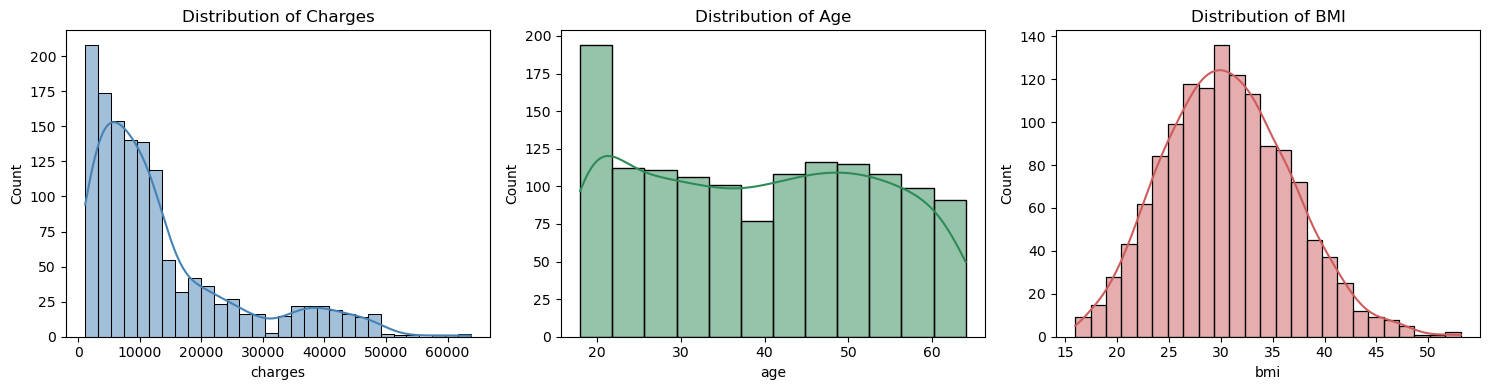

In [7]:
fig, axes = plt.subplots(1, 3, figsize= (15, 4))

sns.histplot(df['charges'], kde= True, ax= axes[0], color= "steelblue")
axes[0].set_title("Distribution of Charges")

sns.histplot(df['age'], kde= True, ax= axes[1], color= "seagreen")
axes[1].set_title("Distribution of Age")

sns.histplot(df['bmi'], kde= True, ax= axes[2], color= "indianred")
axes[2].set_title("Distribution of BMI")

plt.tight_layout()
plt.show()

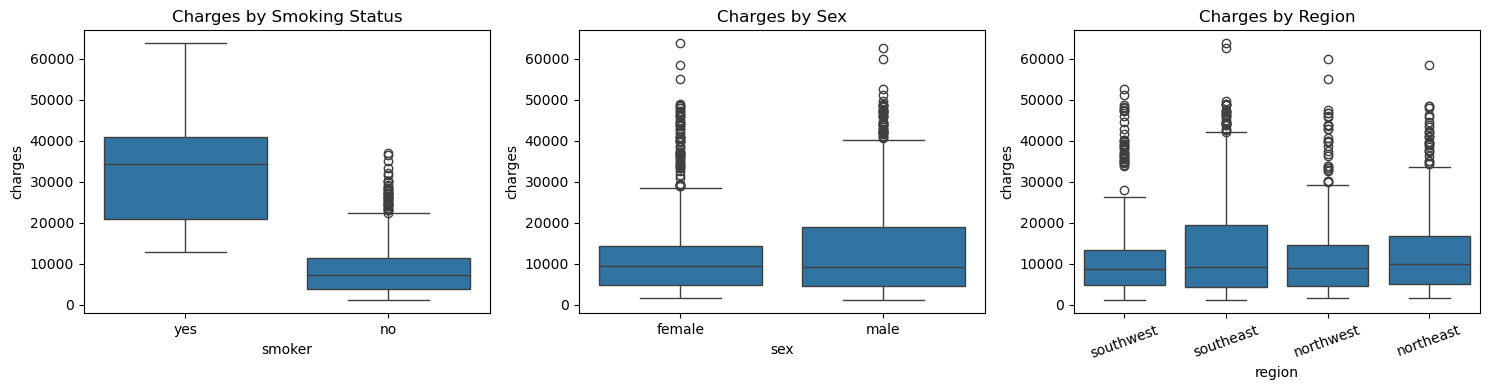

In [8]:
fig, axes = plt.subplots(1, 3, figsize= (15, 4))

sns.boxplot(data= df, x= 'smoker', y= 'charges', ax= axes[0])
axes[0].set_title("Charges by Smoking Status")

sns.boxplot(data= df, x= 'sex', y= 'charges', ax= axes[1])
axes[1].set_title("Charges by Sex")

sns.boxplot(data= df, x= 'region', y= 'charges', ax= axes[2])
axes[2].set_title("Charges by Region")
axes[2].tick_params(axis= 'x', rotation= 20)

plt.tight_layout()
plt.show()

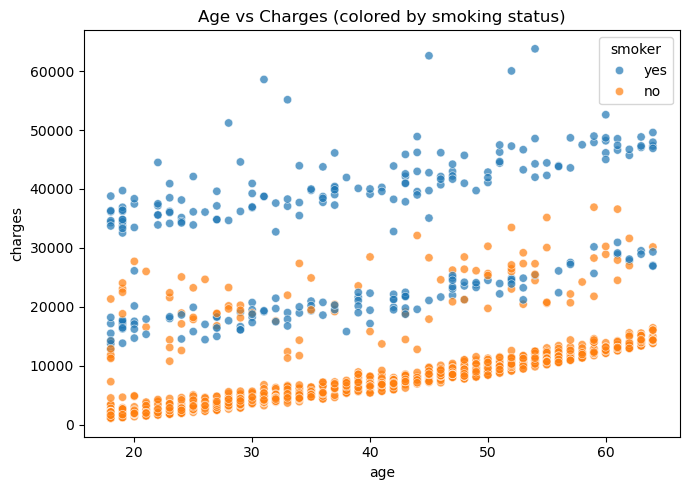

In [9]:
plt.figure(figsize= (7, 5))
sns.scatterplot(data= df, x= 'age', y= 'charges', hue= 'smoker', alpha= 0.7)
plt.title("Age vs Charges (colored by smoking status)")
plt.tight_layout()
plt.show()

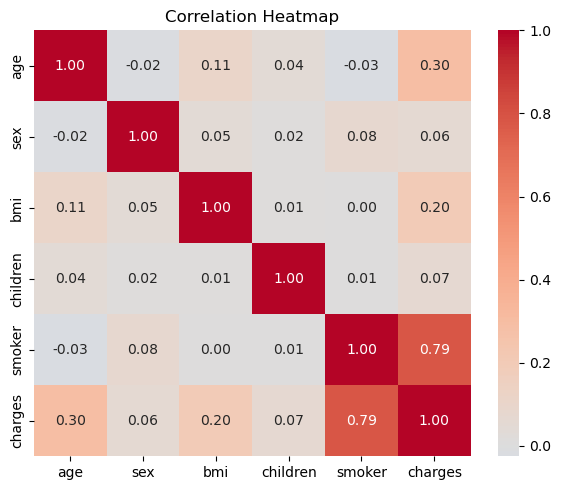

In [10]:
plt.figure(figsize= (6, 5))
numeric_df = df.copy()
numeric_df['sex'] = numeric_df['sex'].map({'female': 0, 'male': 1})
numeric_df['smoker'] = numeric_df['smoker'].map({'no': 0, 'yes': 1})
corr = numeric_df.drop(columns= ['region']).corr()
sns.heatmap(corr, annot= True, fmt= ".2f", cmap= "coolwarm", center= 0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Preprocessing

In [11]:
df.drop_duplicates(inplace= True)
df.shape

(1337, 7)

In [12]:
df["sex"] = df["sex"].map({"female": 0, "male": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

In [14]:
df = pd.get_dummies(df, columns= ["region"], drop_first= True)
bool_cols = df.select_dtypes("bool").columns
df[bool_cols] = df[bool_cols].astype(int)
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [15]:
X = df.drop(columns= ["charges"])
y = df["charges"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
print("\nTrain shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (1069, 8)  Test shape: (268, 8)


# ANN Architecture

In [19]:
n_features = X_train_scaled.shape[1]
 
model = keras.Sequential([
    layers.Input(shape= (n_features,)),
    layers.Dense(32, activation= "relu"),
    layers.Dense(16, activation= "relu"),
    layers.Dense(8, activation= "relu"),
    layers.Dense(1)
])
 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

# Compile & Train

In [20]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [21]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [22]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split =0.2,
    epochs= 150,
    batch_size= 32,
    callbacks= [early_stop],
    verbose= 0
)

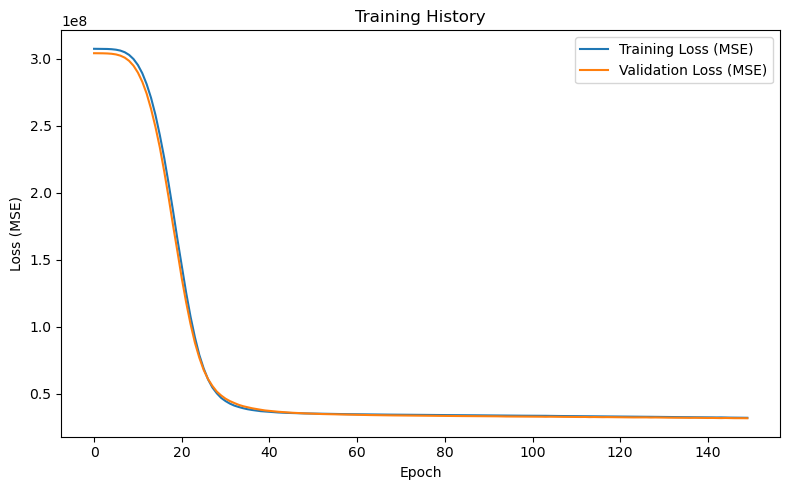

In [23]:
plt.figure(figsize= (8, 5))
plt.plot(history.history["loss"], label= "Training Loss (MSE)")
plt.plot(history.history["val_loss"], label= "Validation Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training History")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate the Model

In [24]:
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [25]:
print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.2f}")
print(f"R² Score: {r2:.2f}")


--- Model Evaluation ---
Mean Absolute Error (MAE): 3845.16
Root Mean Squared Error (RMSE): 5608.76
R² Score: 0.83


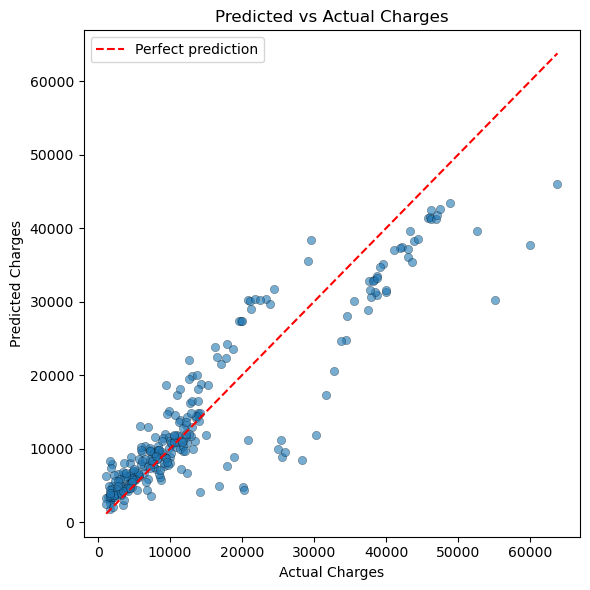

In [26]:
plt.figure(figsize= (6, 6))
plt.scatter(y_test, y_pred, alpha= 0.6, edgecolor= 'k', linewidth= 0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label= "Perfect prediction")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Predicted vs Actual Charges")
plt.legend()
plt.tight_layout()
plt.show()

# Save Results

In [ ]:
import pickle
with open('Insurance_model.pkl', 'wb') as file:
    pickle.dump(model, file)